<a href="https://colab.research.google.com/github/artemsorokin120504-star/-2026-103-/blob/main/Lab09_telecom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Упражнение 9

In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

--2026-05-29 18:16:27--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-29 18:16:27--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.006s  

2026-05-29 18:16:27 (7.51 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



Пункт 1

In [2]:
if not os.path.exists('FB_2.csv'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/FB_2.csv
import pandas as pd

df = pd.read_csv('FB_2.csv', header=0, parse_dates=[0])
len(df)

--2026-05-29 18:16:31--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/FB_2.csv
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/FB_2.csv [following]
--2026-05-29 18:16:32--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/FB_2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 143920 (141K) [text/plain]
Saving to: ‘FB_2.csv’

FB_2.csv            100%[===================>] 140.55K  --.-KB/s    in 0.01s   

2026-05-29 18:16:32 (11.0 MB/s) - ‘FB_2.csv’ saved [143920/143920]



1977

In [3]:
from thinkdsp import Wave

ys = df['Close']

# for these examples, we need the wave to have
# an even number of samples
if len(ys) % 2:
    ys = ys[:-1]

close = Wave(ys, framerate=1)
len(close)

1976

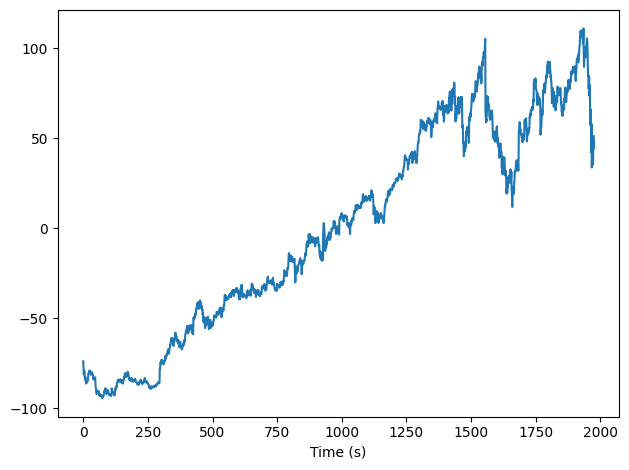

In [4]:
from thinkdsp import SawtoothSignal

in_wave = close
in_wave.unbias()
in_wave.plot()
decorate(xlabel='Time (s)')

Вот спектр сигнала до применения накопительной суммы:

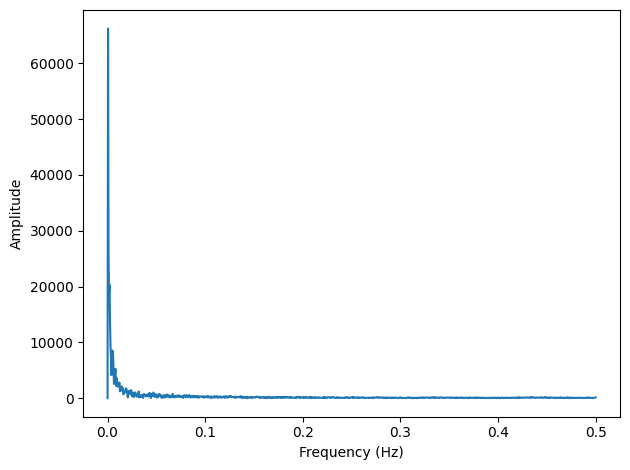

In [5]:
in_spectrum = in_wave.make_spectrum()
in_spectrum.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

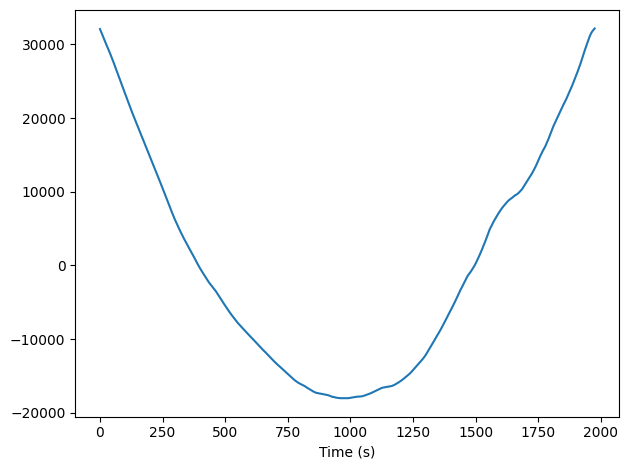

In [6]:
out_wave = in_wave.cumsum()
out_wave.unbias()
out_wave.plot()
decorate(xlabel='Time (s)')

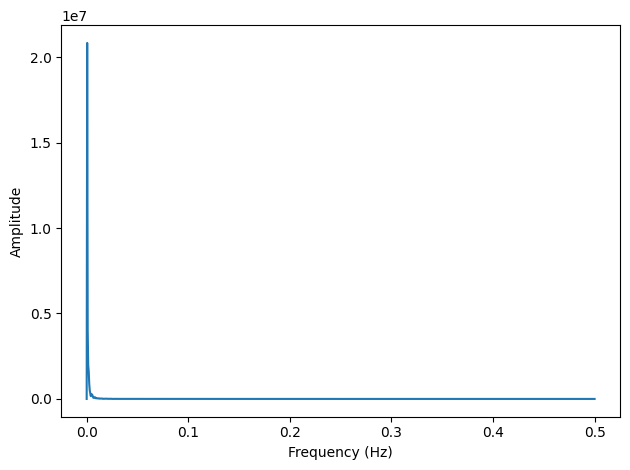

In [7]:
out_spectrum = out_wave.make_spectrum()
out_spectrum.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

In [8]:
sum(in_spectrum.amps < 1), len(in_spectrum)

(np.int64(1), 989)

Между гармониками компоненты сигнала пренебрежимо малы → заменены на NaN.

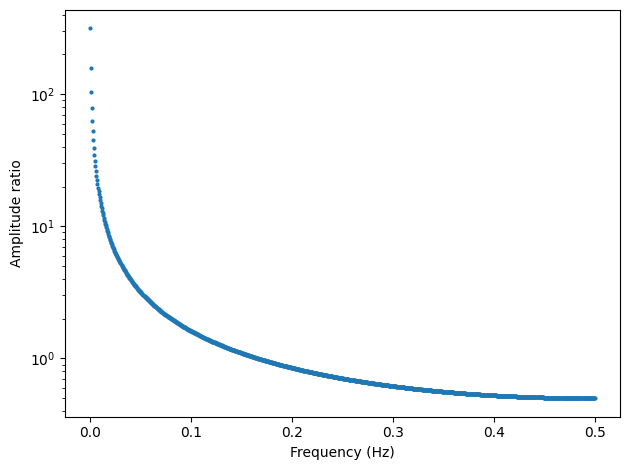

In [9]:
ratio_spectrum = out_spectrum.ratio(in_spectrum, thresh=1)
ratio_spectrum.plot(marker='.', ms=4, ls='')

decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude ratio',
         yscale='log')

Фильтр накопительной суммы = инверсия фильтра разности.

Подтверждено совпадением расчётов.

In [10]:
from thinkdsp import zero_pad

# compute the diff filter
diff_window = np.array([1.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()

In [11]:
# compute the cumsum filter by inverting the diff filter
cumsum_filter = diff_filter.copy()
cumsum_filter.hs[1:] = 1 / cumsum_filter.hs[1:]
cumsum_filter.hs[0] = np.inf

In [12]:
# compute the integration filter
integ_filter = cumsum_filter.copy()
integ_filter.hs[1:] = integ_filter.framerate / (np.pi * 2 * 1j * integ_filter.fs[1:])
integ_filter.hs[0] = np.inf

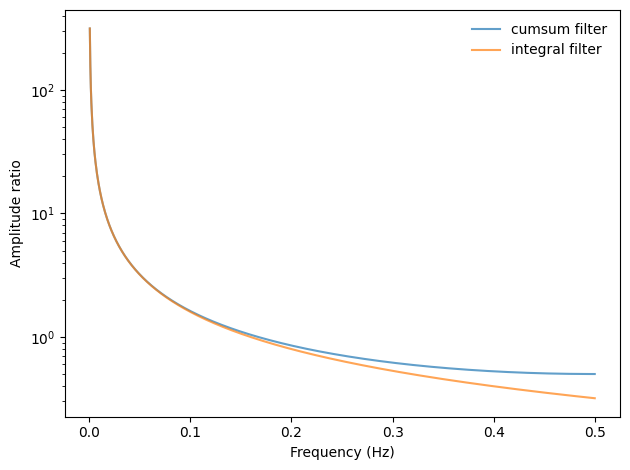

In [13]:
cumsum_filter.plot(label='cumsum filter', alpha=0.7)
integ_filter.plot(label='integral filter', alpha=0.7)

decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude ratio',
         yscale='log')

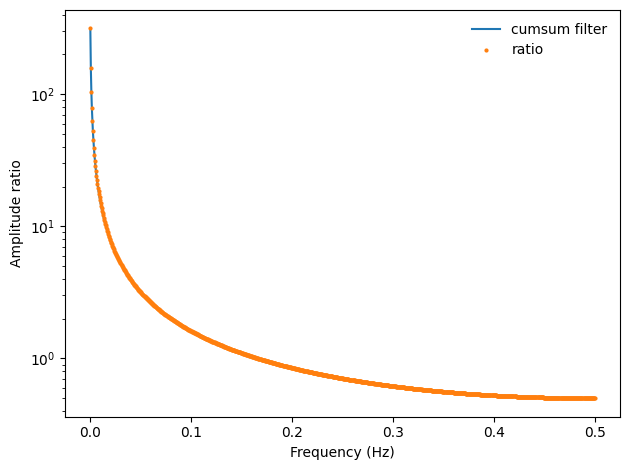

In [14]:
cumsum_filter.plot(label='cumsum filter')
ratio_spectrum.plot(label='ratio', marker='.', ms=4, ls='')
decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude ratio',
         yscale='log')

In [15]:
len(in_spectrum), len(cumsum_filter)

(989, 989)

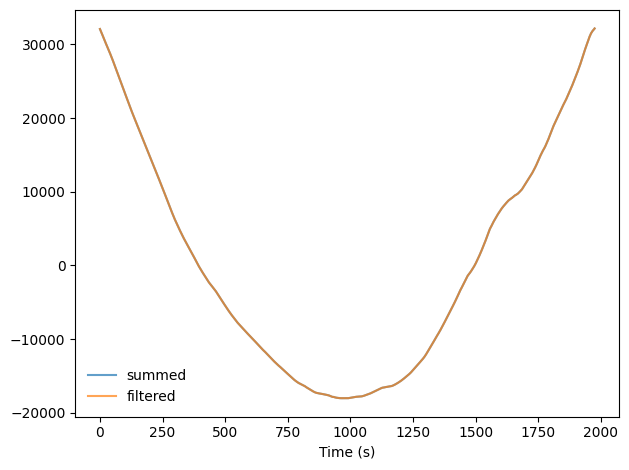

In [16]:
out_wave.plot(label='summed', alpha=0.7)

cumsum_filter.hs[0] = 0
out_wave2 = (in_spectrum * cumsum_filter).make_wave()
out_wave2.plot(label='filtered', alpha=0.7)

decorate(xlabel='Time (s)')

In [17]:
out_wave.max_diff(out_wave2)

np.float64(1.659827830735594e-10)

Пункт 2

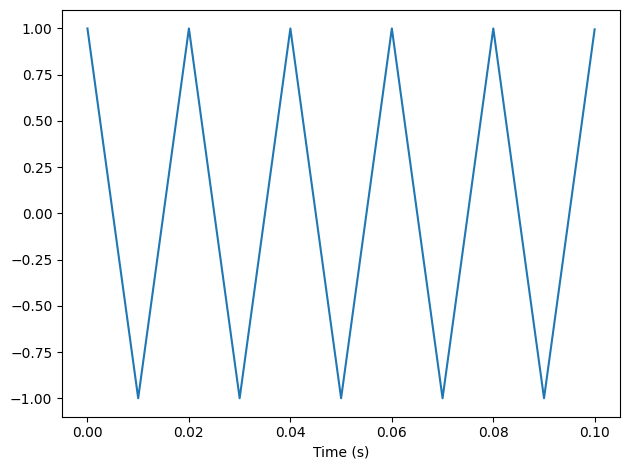

In [18]:
from thinkdsp import TriangleSignal

in_wave = TriangleSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Time (s)')

Разность треугольной волны → прямоугольная волна:

Объясняет различие в затухании гармоник:

Прямоугольная:
1/f


Треугольная: 1/f^2


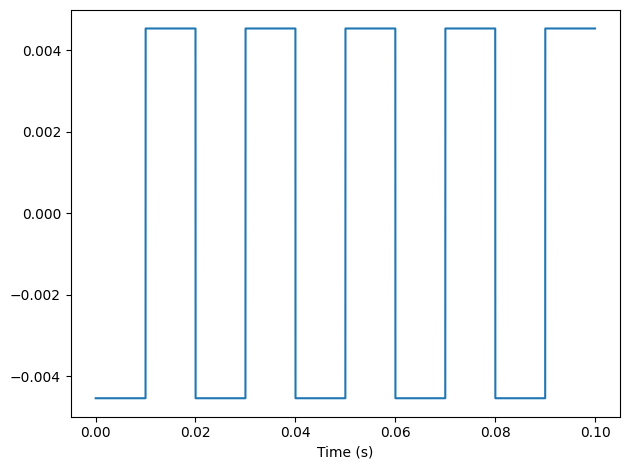

In [19]:
out_wave = in_wave.diff()
out_wave.plot()
decorate(xlabel='Time (s)')

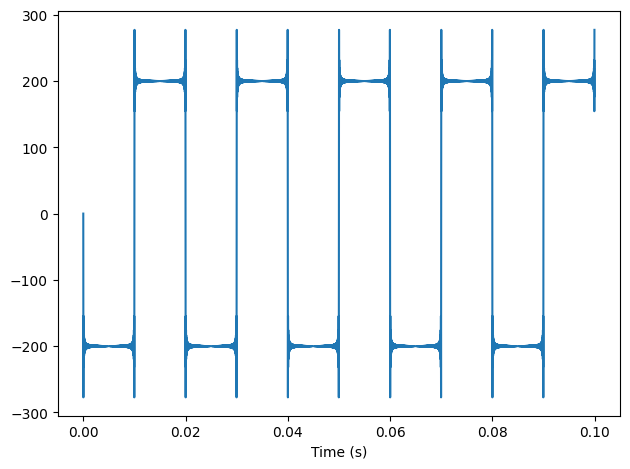

In [20]:
out_wave2 = in_wave.make_spectrum().differentiate().make_wave()
out_wave2.plot()
decorate(xlabel='Time (s)')

Пункт 3

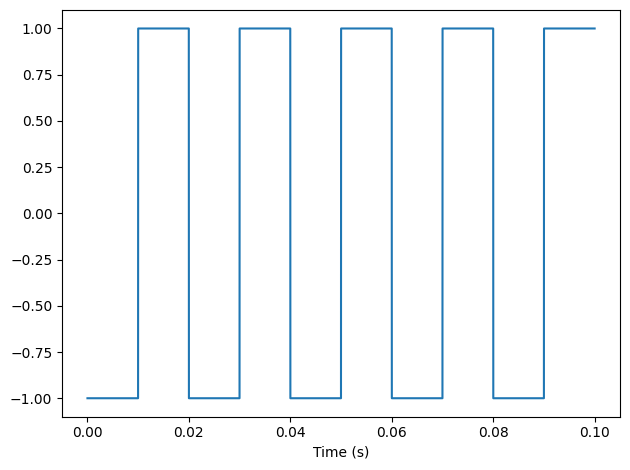

In [21]:
from thinkdsp import SquareSignal

in_wave = SquareSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Time (s)')

Накопительная сумма прямоугольной волны → треугольная волна (ожидаемо из предыдущих опытов).

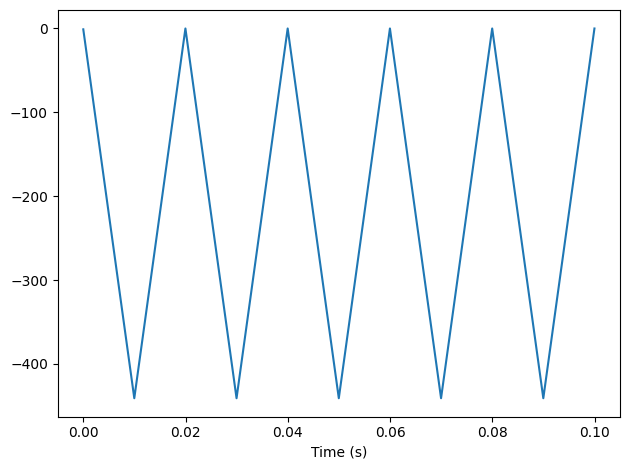

In [22]:
out_wave = in_wave.cumsum()
out_wave.plot()
decorate(xlabel='Time (s)')

Производная треугольной волны:

Не определена в пиках → вызывает "звон" (артефакты Гиббса).

Спектральный интеграл прямоугольной волны:

Даёт треугольную волну, но с иной амплитудой.

Многократное интегрирование приближает сигнал к синусоиде (действует как ФНЧ, оставляя основную гармонику).

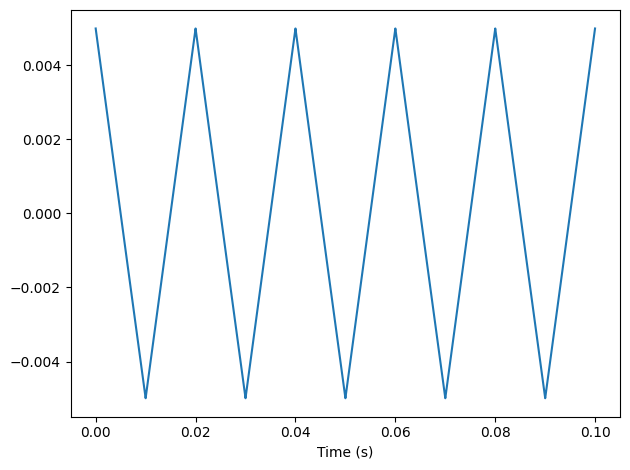

In [23]:
spectrum = in_wave.make_spectrum().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Time (s)')

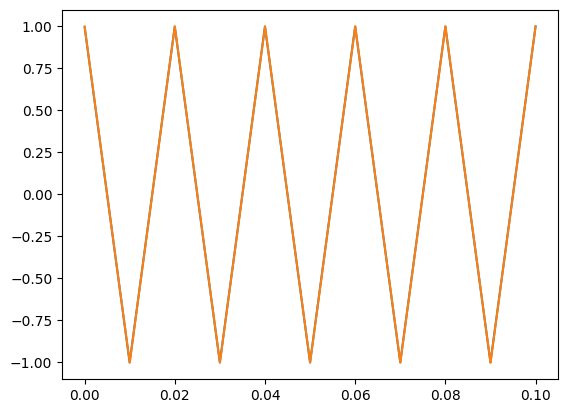

In [24]:
out_wave.unbias()
out_wave.normalize()
out_wave2.normalize()
out_wave.plot()
out_wave2.plot()

In [25]:
out_wave.max_diff(out_wave2)

np.float64(0.0045351473922902175)

Пункт 4

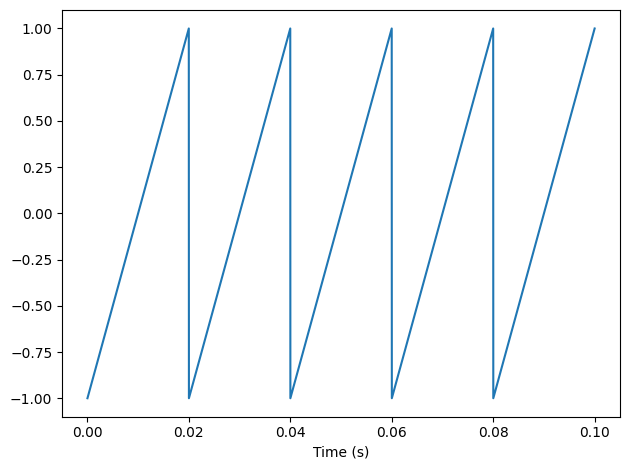

In [26]:
from thinkdsp import SawtoothSignal

in_wave = SawtoothSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Time (s)')

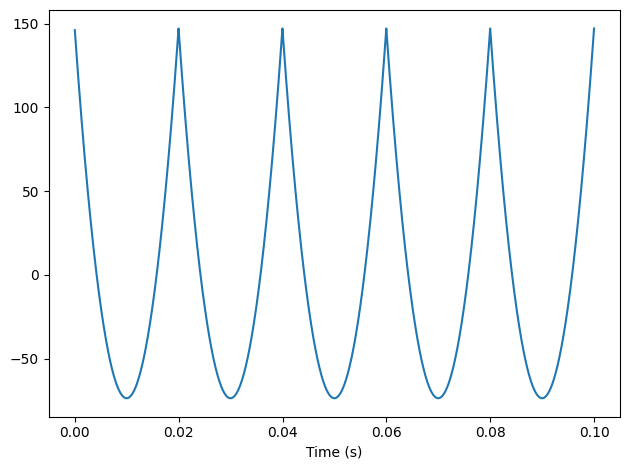

In [27]:
out_wave = in_wave.cumsum()
out_wave.unbias()
out_wave.plot()
decorate(xlabel='Time (s)')

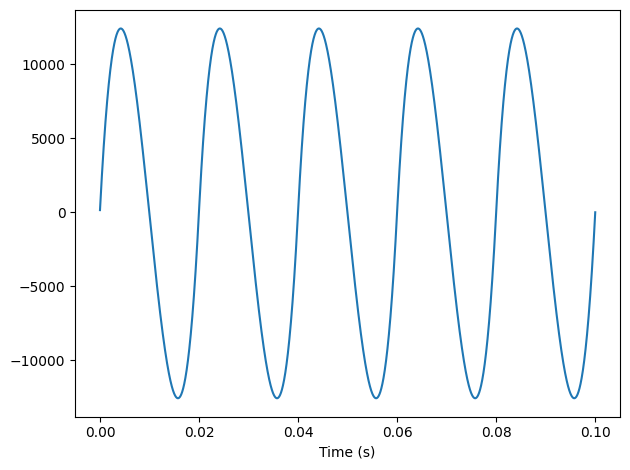

In [28]:
out_wave = out_wave.cumsum()
out_wave.plot()
decorate(xlabel='Time (s)')

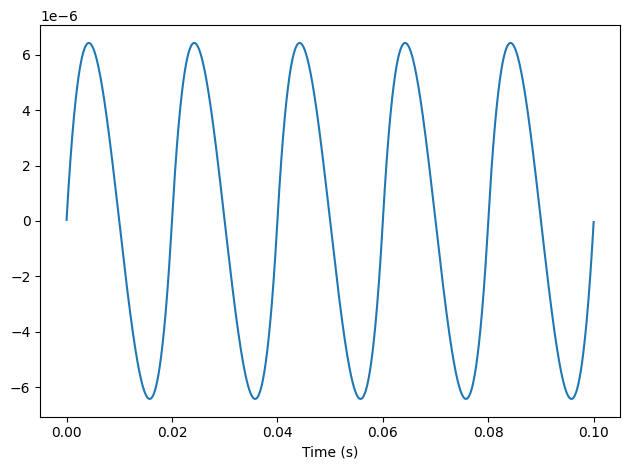

In [29]:
spectrum = in_wave.make_spectrum().integrate().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Time (s)')

Двойное дифференцирование:

Пилообразная волна + "звон" (из-за разрывов производной).

Сравнение фильтров:

Оба — фильтры верхних частот (усиливают высокие частоты).

Вторая производная:

Параболический характер → резкое усиление самых высоких частот.

Вторая разность:

Аппроксимирует вторую производную только на низких частотах → значительные отклонения на высоких.

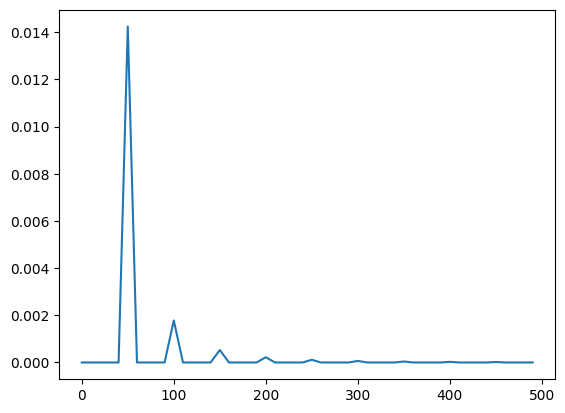

In [30]:
out_wave2.make_spectrum().plot(high=500)

Пункт 5

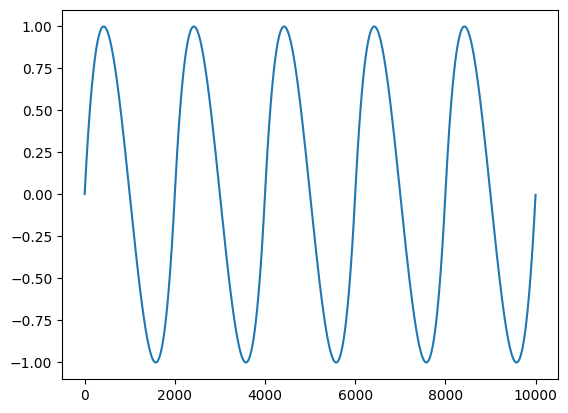

In [31]:
from thinkdsp import CubicSignal

in_wave = CubicSignal(freq=0.0005).make_wave(duration=10000, framerate=1)
in_wave.plot()

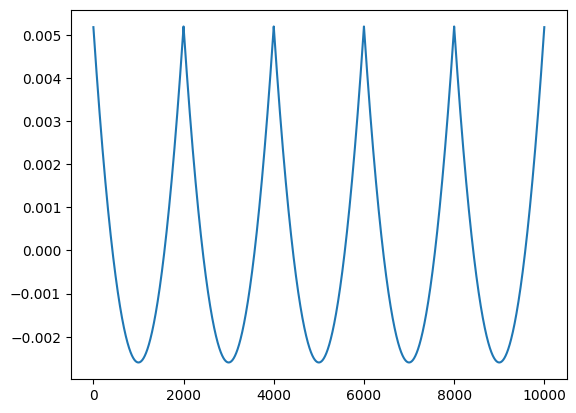

In [32]:
out_wave = in_wave.diff()
out_wave.plot()

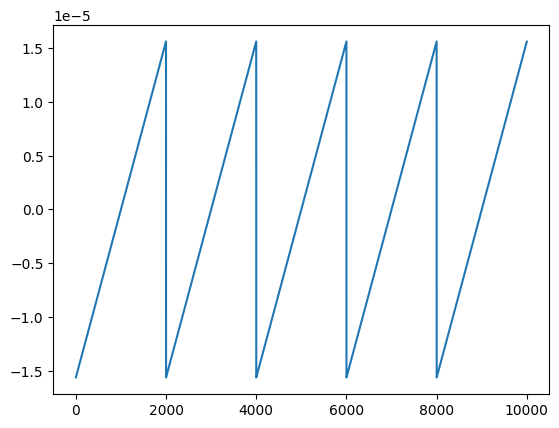

In [33]:
out_wave = out_wave.diff()
out_wave.plot()

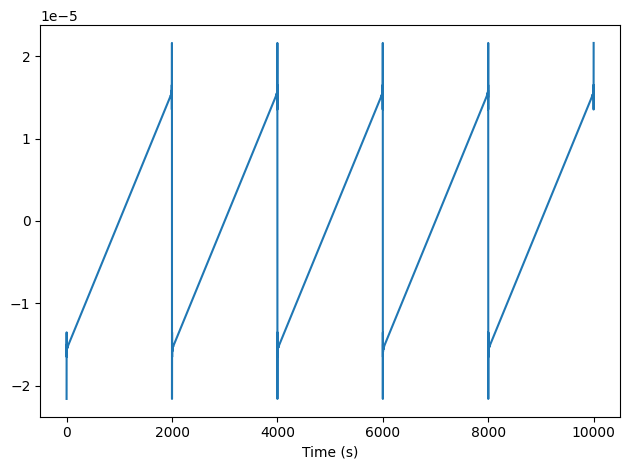

In [34]:
spectrum = in_wave.make_spectrum().differentiate().differentiate()
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Time (s)')

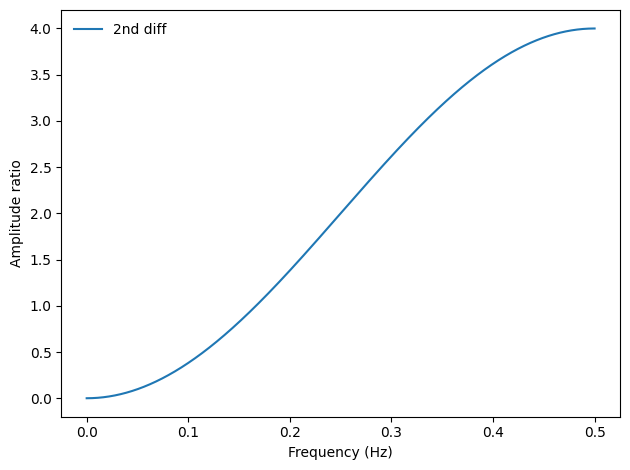

In [35]:
from thinkdsp import Wave

diff_window = np.array([-1.0, 2.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()
diff_filter.plot(label='2nd diff')

decorate(xlabel='Frequency (Hz)',
                 ylabel='Amplitude ratio')

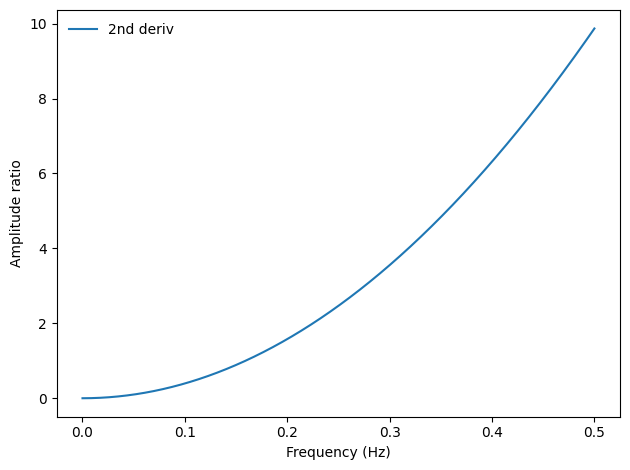

In [36]:
PI2 = np.pi * 2

deriv_filter = in_wave.make_spectrum()
deriv_filter.hs = (PI2 * 1j * deriv_filter.fs)**2
deriv_filter.plot(label='2nd deriv')

decorate(xlabel='Frequency (Hz)',
                 ylabel='Amplitude ratio')

Оба фильтра являются фильтрами верхних частот, усиливающими компоненты с наивысшей частотой. Вторая производная — это парабола, поэтому она усиливает самые высокие частоты. Вторая разность является хорошим приближением второй производной только на самых низких частотах, после чего она существенно отклоняется.

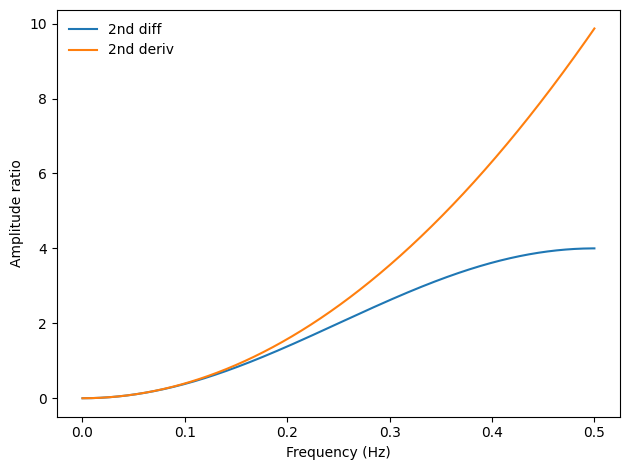

In [37]:
diff_filter.plot(label='2nd diff')
deriv_filter.plot(label='2nd deriv')

decorate(xlabel='Frequency (Hz)',
                 ylabel='Amplitude ratio')